# Simple Fiber Instance Segementation with Watershed

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/segment-anything-2/blob/dev/notebooks/promotion/simple_analysis.ipynb)

## Environment Set-up

In [2]:
using_colab = False

In [5]:
# ===========================================================
# Imports
# ===========================================================
from __future__ import annotations

import sys
from pathlib import Path
from time import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm

from scipy import ndimage as ndi
from skimage.filters import threshold_otsu
from skimage.feature import peak_local_max
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects
from skimage.segmentation import watershed


# ===========================================================
# Optional: Google Colab setup
# ===========================================================
USING_COLAB = False  # set True if running on Colab

if USING_COLAB:
    # Install required packages
    !{sys.executable} -m pip install -q opencv-python matplotlib
    !{sys.executable} -m pip install -q "git+https://github.com/choROPeNt/segment-anything-2.git@dev"

    # Download SAM2 model checkpoint
    !mkdir -p ./checkpoints/
    !wget -q -P ./checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt

import sam2
from sam2.addons import show_anns

## Set-up

Necessary imports and helper functions for displaying points, boxes, and masks.

In [6]:
# -----------------------------------------------------------
# Select device (CUDA → MPS → CPU)
# -----------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # fallback for unsupported ops
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using PyTorch Version {torch.__version__}")
print(f"Using device: {device}")

# -----------------------------------------------------------
# CUDA-specific optimizations
# -----------------------------------------------------------
if device.type == "cuda":
    # Enable bfloat16 autocast for entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

    # Enable TensorFloat-32 (TF32) on Ampere or newer GPUs
    props = torch.cuda.get_device_properties(0)
    if props.major >= 8:  # Ampere or newer
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

# -----------------------------------------------------------
# MPS warning (Apple Silicon)
# -----------------------------------------------------------
elif device.type == "mps":
    print(
        "\n⚠️  Warning: MPS support in PyTorch is still experimental.\n"
        "    SAM2 is trained on CUDA and may produce slightly different\n"
        "    numerical results or slower performance on MPS.\n"
        "    More details: https://github.com/pytorch/pytorch/issues/84936\n"
    )

Using PyTorch Version 2.8.0
Using device: mps

⚠️  Warning: MPS support in PyTorch is still experimental.
    SAM2 is trained on CUDA and may produce slightly different
    numerical results or slower performance on MPS.
    More details: https://github.com/pytorch/pytorch/issues/84936



## Example image

In [30]:
file_path = Path('../../data/promotion/245_004.tiff')

image = Image.open(file_path)
image_np = np.array(image.convert("L"))
print(f"Loaded image with shape: {image_np.shape} and dtype: {image_np.dtype} as NumPy array")

Loaded image with shape: (1523, 13772) and dtype: uint8 as NumPy array


In [27]:
mask = Image.open('../../data/promotion/245_004.mask.tif')
mask_np = np.array(mask.convert("L")).astype(bool)
print(f"Loaded image mask with shape: {mask_np.shape} and dtype: {mask_np.dtype} as NumPy array")

Loaded image mask with shape: (1523, 13772) and dtype: bool as NumPy array


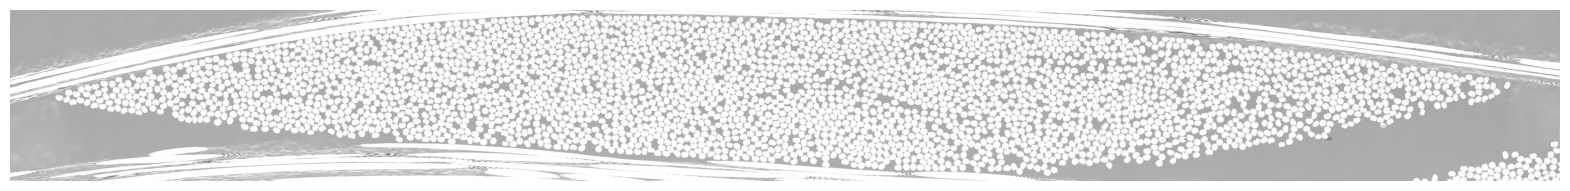

In [23]:
plt.figure(figsize=(20, 4))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

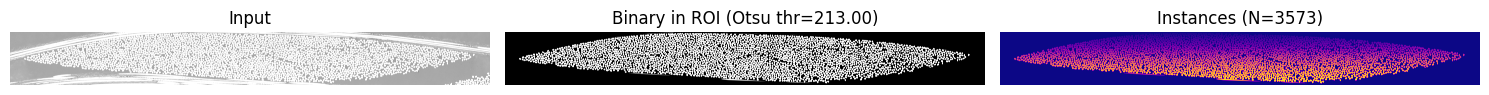

In [53]:
# --- ensure boolean mask ---
mask_bool = mask_np.astype(bool)

# --- compute Otsu threshold using ONLY pixels inside mask ---
roi_vals = image_np[mask_bool]
thresh = threshold_otsu(roi_vals)

# --- threshold only inside ROI ---
binary = np.zeros_like(image_np, dtype=bool)
binary[mask_bool] = image_np[mask_bool] > thresh + 20 # optionally: thresh - offset

# Optional cleanup (tune these!)
binary = remove_small_objects(binary, min_size=200)
binary = remove_small_holes(binary, area_threshold=200)

# keep everything strictly inside ROI
binary &= mask_bool

# --- 2) Instance segmentation (watershed on distance map) ---
distance = ndi.distance_transform_edt(binary)

coords = peak_local_max(distance, labels=binary, min_distance=10)
markers = np.zeros_like(image_np, dtype=np.int32)
markers[coords[:, 0], coords[:, 1]] = 1
markers = label(markers)

labels_ws = watershed(-distance, markers, mask=binary)

# --- 3) Plot ---
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image_np, cmap="gray")
ax[0].set_title("Input")
ax[0].axis("off")

ax[1].imshow(binary, cmap="gray")
ax[1].set_title(f"Binary in ROI (Otsu thr={thresh:.2f})")
ax[1].axis("off")

ax[2].imshow(labels_ws, cmap="plasma")
ax[2].set_title(f"Instances (N={labels_ws.max()})")
ax[2].axis("off")

plt.tight_layout()
plt.show()


In [64]:
from skimage.measure import regionprops

sorted_masks = []

for region in regionprops(labels_ws):
    minr, minc, maxr, maxc = region.bbox  # (ymin, xmin, ymax, xmax)

    xmin = int(minc)
    ymin = int(minr)
    w = int(maxc - minc)
    h = int(maxr - minr)

    cropped_mask = (labels_ws[minr:maxr, minc:maxc] == region.label)

    seg = {
        "id": int(region.label),
        "area": int(region.area),
        "diameter": float(region.equivalent_diameter),
        "bbox": (xmin, ymin, w, h),  # <- now in requested format
        "centroid": tuple(region.centroid),
        "segmentation_crop": cropped_mask.astype(np.uint8)
    }

    sorted_masks.append(seg)


sorted_masks = sorted(sorted_masks, key=lambda m: m["diameter"], reverse=True)


spacing = 0.11688678457992144

diameters = [obj["diameter"] for obj in sorted_masks]
avg_diameter = np.mean(diameters)*spacing
print(f"Average diameter in microns: {avg_diameter:.2f} µm")


Average diameter in microns: 5.81 µm


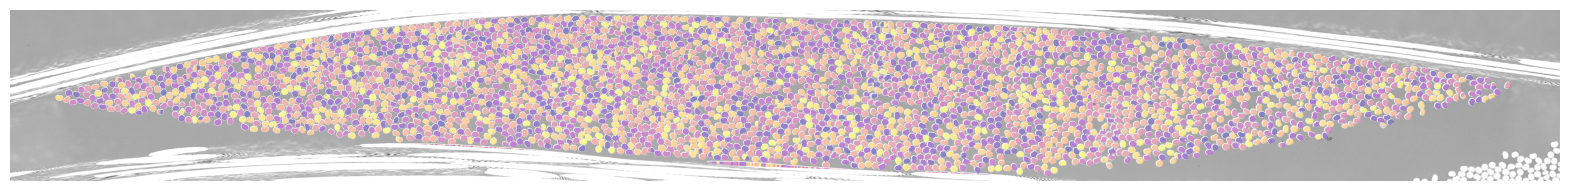

In [65]:
# Display segmented masks on top of the image
plt.figure(figsize=(20, 5))
plt.imshow(image_np, cmap="gray")

# Random-color instance masks using the "plasma" colormap
label_canvas = show_anns(
    sorted_masks,
    alpha=0.5,
    borders =False,          # overlay transparency (0=transparent, 1=opaque)
    cmap_key="plasma"   # Matplotlib colormap for mask colors
)

plt.axis('off')
plt.show()

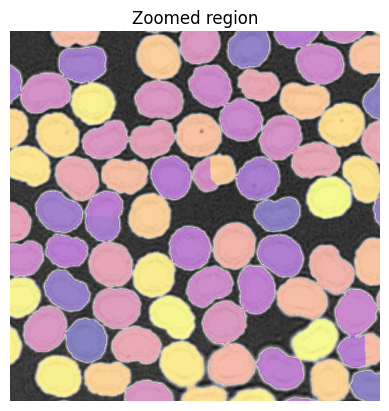

In [66]:
y0, x0 = 500,2000
size = 512



plt.imshow(image_np[y0:y0+size, x0:x0+size], cmap="gray")
plt.imshow(label_canvas[y0:y0+size, x0:x0+size,:])
plt.axis("off")
plt.title("Zoomed region")
plt.show()

## 💾 Save the labels mask as a TIFF file

In [ ]:
output_path = file_path.parent / f"{file_path.stem}.labels.tiff"

Image.fromarray(labels_ws.astype(np.uint16)).save(output_path)